In [1]:
import pandas as pd

In [2]:
df = pd.read_csv('Csv_Anti‑Money_Laundering_Monitoring.csv')

In [3]:
df.head()

,Time,Date,Sender_account,Receiver_account,Amount,Payment_currency,Received_currency,Sender_bank_location,Receiver_bank_location,Payment_type,Is_laundering,Laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [4]:
df.shape

(9504852, 12)

In [5]:
df.dtypes

Time                       object
Date                       object
Sender_account              int64
Receiver_account            int64
Amount                    float64
Payment_currency           object
Received_currency          object
Sender_bank_location       object
Receiver_bank_location     object
Payment_type               object
Is_laundering               int64
Laundering_type            object
dtype: object

In [6]:
df.isnull().sum()

Time                      0
Date                      0
Sender_account            0
Receiver_account          0
Amount                    0
Payment_currency          0
Received_currency         0
Sender_bank_location      0
Receiver_bank_location    0
Payment_type              0
Is_laundering             0
Laundering_type           0
dtype: int64

In [7]:
df.columns = df.columns.str.lower()
df.columns

Index(['time', 'date', 'sender_account', 'receiver_account', 'amount',
       'payment_currency', 'received_currency', 'sender_bank_location',
       'receiver_bank_location', 'payment_type', 'is_laundering',
       'laundering_type'],
      dtype='object')

In [8]:
df.head()

,time,date,sender_account,receiver_account,amount,payment_currency,received_currency,sender_bank_location,receiver_bank_location,payment_type,is_laundering,laundering_type
0,10:35:19,2022-10-07,8724731955,2769355426,1459.15,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits
1,10:35:20,2022-10-07,1491989064,8401255335,6019.64,UK pounds,Dirham,UK,UAE,Cross-border,0,Normal_Fan_Out
2,10:35:20,2022-10-07,287305149,4404767002,14328.44,UK pounds,UK pounds,UK,UK,Cheque,0,Normal_Small_Fan_Out
3,10:35:21,2022-10-07,5376652437,9600420220,11895.00,UK pounds,UK pounds,UK,UK,ACH,0,Normal_Fan_In
4,10:35:21,2022-10-07,9614186178,3803336972,115.25,UK pounds,UK pounds,UK,UK,Cash Deposit,0,Normal_Cash_Deposits


In [9]:
df.isnull().sum()

time                      0
date                      0
sender_account            0
receiver_account          0
amount                    0
payment_currency          0
received_currency         0
sender_bank_location      0
receiver_bank_location    0
payment_type              0
is_laundering             0
laundering_type           0
dtype: int64

In [10]:
df.dtypes

time                       object
date                       object
sender_account              int64
receiver_account            int64
amount                    float64
payment_currency           object
received_currency          object
sender_bank_location       object
receiver_bank_location     object
payment_type               object
is_laundering               int64
laundering_type            object
dtype: object

In [11]:
df['payment_currency'].value_counts()

payment_currency
UK pounds          9099293
Euro                117164
Turkish lira         27996
Swiss franc          27492
Dirham               27263
Pakistani rupee      27196
Naira                27143
US dollar            26061
Yen                  25562
Moroccan dirham      25395
Mexican Peso         24852
Albanian lek         24778
Indian rupee         24657
Name: count, dtype: int64

In [12]:
# Encode categorical variables
df_encoded = pd.get_dummies(df, columns=[
    'payment_currency', 'received_currency',
    'sender_bank_location', 'receiver_bank_location',
    'payment_type', 'laundering_type'
])

In [13]:
# Features and target
X = df_encoded.drop(['is_laundering','time','date'], axis=1)
y = df_encoded['is_laundering']

In [14]:
# Train/Test Split
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=42, stratify=y)

In [15]:
# Random Forest Classifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix

rf = RandomForestClassifier(n_estimators=40, random_state=42)
rf.fit(X_train, y_train)

y_pred = rf.predict(X_test)

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

[[2848494       0]
 [      0    2962]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2848494
           1       1.00      1.00      1.00      2962

    accuracy                           1.00   2851456
   macro avg       1.00      1.00      1.00   2851456
weighted avg       1.00      1.00      1.00   2851456



In [17]:
# Logistic Regression
from sklearn.linear_model import LogisticRegression

logreg = LogisticRegression(max_iter=1000)
logreg.fit(X_train, y_train)

y_pred_lr = logreg.predict(X_test)

print(classification_report(y_test, y_pred_lr, zero_division=0))

              precision    recall  f1-score   support

           0       1.00      1.00      1.00   2848494
           1       0.00      0.00      0.00      2962

    accuracy                           1.00   2851456
   macro avg       0.50      0.50      0.50   2851456
weighted avg       1.00      1.00      1.00   2851456



In [18]:
# Unsupervised Anomaly Detection
from sklearn.ensemble import IsolationForest

iso = IsolationForest(contamination=0.01, random_state=42)
df['anomaly_flag'] = iso.fit_predict(df[['amount']])

# -1 = anomaly, 1 = normal
print(df['anomaly_flag'].value_counts())

anomaly_flag
 1    9410894
-1      93958
Name: count, dtype: int64


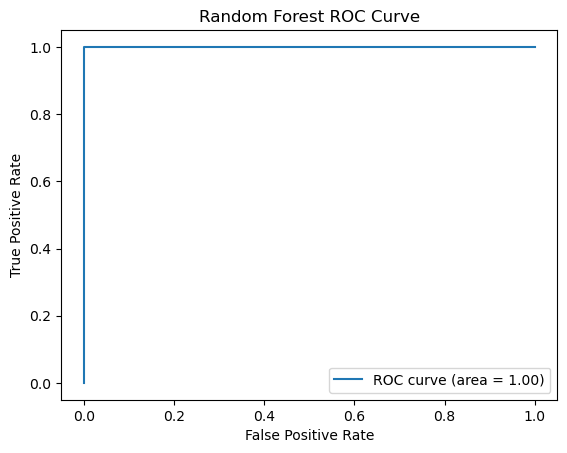

In [19]:
# Model Evaluation
from sklearn.metrics import roc_curve, auc
import matplotlib.pyplot as plt

y_prob = rf.predict_proba(X_test)[:,1]
fpr, tpr, thresholds = roc_curve(y_test, y_prob)
roc_auc = auc(fpr, tpr)

plt.plot(fpr, tpr, label=f'ROC curve (area = {roc_auc:.2f})')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Random Forest ROC Curve')
plt.legend()
plt.show()